<h3 align="center">Capstone project</h3>
<h1 align="center">Communities and Crime Dataset</h1>
<h3 align="center">Matúš Koleják, Branislav Trstenský</h3>

> Dataset: UCI Machine Learning Repository (ID: 183)\
> Redmond, M. (2002). Communities and Crime.\
> <https://doi.org/10.24432/C53W3X>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

Task 5: Dimensionality Reduction on Communities and Crime Dataset
=================================================================
Apply PCA, LDA, and related techniques before regression/classification.
Compare approaches, explain feature space transformations, and evaluate
whether explainable ML remains feasible after reduction.

### Load and prepare data

In [6]:
df = pd.read_csv("../data/data.csv", na_values="?")
X = df.drop("ViolentCrimesPerPop", axis=1)
y = df[["ViolentCrimesPerPop"]]

print(f"Original shape: X={X.shape}, y={y.shape}")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Original shape: X=(1994, 127), y=(1994, 1)
Features: 127, Samples: 1994


In [7]:
# Drop non-predictive columns
non_predictive = ['state', 'county', 'community', 'communityname', 'fold']
X = X.drop(columns=[c for c in non_predictive if c in X.columns], errors='ignore')

# Drop any remaining non-numeric columns
X = X.select_dtypes(include=[np.number])

# Handle missing values - drop columns with >50% missing, impute rest with median
missing_pct = X.isnull().mean()
high_missing = missing_pct[missing_pct > 0.5].index.tolist()
print(f"\nDropped {len(high_missing)} columns with >50% missing values:")
print(f"  {high_missing[:5]}... (LEMAS variables)")
X = X.drop(columns=high_missing)

# Impute remaining missing values with median
X = X.fillna(X.median())

# Target variable
y = y.values.ravel()
print(f"\nFinal shape after cleaning: X={X.shape}")
print(f"Target (ViolentCrimesPerPop): mean={y.mean():.3f}, std={y.std():.3f}")

feature_names = X.columns.tolist()



Dropped 22 columns with >50% missing values:
  ['LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq']... (LEMAS variables)

Final shape after cleaning: X=(1994, 100)
Target (ViolentCrimesPerPop): mean=0.238, std=0.233


### Standardization

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA - Principal Component Analysis

Components needed for 90% variance: 23
Components needed for 95% variance: 35
Components needed for 99% variance: 59
Total features: 100


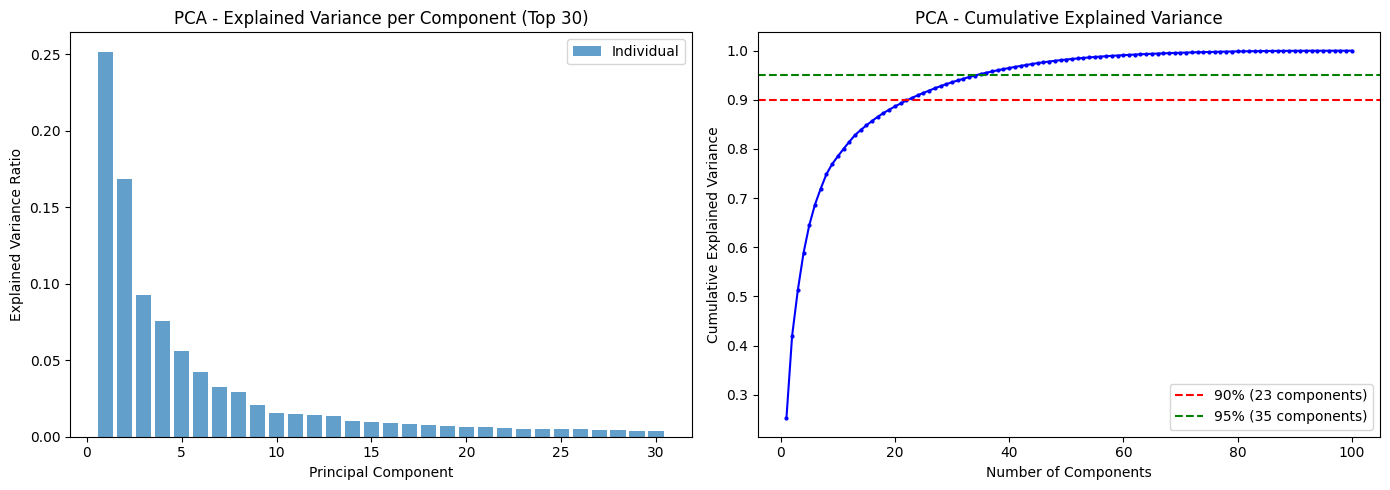

In [10]:
# Full PCA to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")
print(f"Total features: {X_scaled.shape[1]}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30], alpha=0.7, label='Individual')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA - Explained Variance per Component (Top 30)')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-o', markersize=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label=f'90% ({n_90} components)')
axes[1].axhline(y=0.95, color='g', linestyle='--', label=f'95% ({n_95} components)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA - Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/task5_pca_variance.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# PCA with chosen number of components
pca = PCA(n_components=n_95)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA reduced: {X_scaled.shape[1]} -> {X_pca.shape[1]} features (95% variance retained)")

# Top feature loadings for first 3 PCs
print("\nTop 5 feature loadings per principal component (PC1-PC3):")
for i in range(min(3, pca.n_components_)):
    loadings = pd.Series(pca.components_[i], index=feature_names)
    top_pos = loadings.nlargest(3)
    top_neg = loadings.nsmallest(3)
    print(f"\n  PC{i+1} (explains {pca.explained_variance_ratio_[i]*100:.1f}% variance):")
    print(f"    Positive: {', '.join([f'{n}({v:.3f})' for n, v in top_pos.items()])}")
    print(f"    Negative: {', '.join([f'{n}({v:.3f})' for n, v in top_neg.items()])}")


PCA reduced: 100 -> 35 features (95% variance retained)

Top 5 feature loadings per principal component (PC1-PC3):

  PC1 (explains 25.2% variance):
    Positive: medFamInc(0.183), medIncome(0.182), PctKids2Par(0.175)
    Negative: PctPopUnderPov(-0.173), pctWPubAsst(-0.164), PctHousNoPhone(-0.164)

  PC2 (explains 16.8% variance):
    Positive: PctRecImmig10(0.219), PctRecImmig8(0.219), PctRecImmig5(0.217)
    Negative: PctSpeakEnglOnly(-0.191), PctBornSameState(-0.128), pctWSocSec(-0.120)

  PC3 (explains 9.3% variance):
    Positive: PersPerOccupHous(0.254), PersPerFam(0.232), PersPerOwnOccHous(0.224)
    Negative: HousVacant(-0.170), numbUrban(-0.151), population(-0.149)


### LDA - Linear Discriminant Analysis

Target discretized into 5 classes for LDA
Class distribution: [484 315 422 387 386]
LDA reduced: 100 -> 4 features
LDA explained variance ratios: [0.83715466 0.11661786 0.02879624 0.01743124]


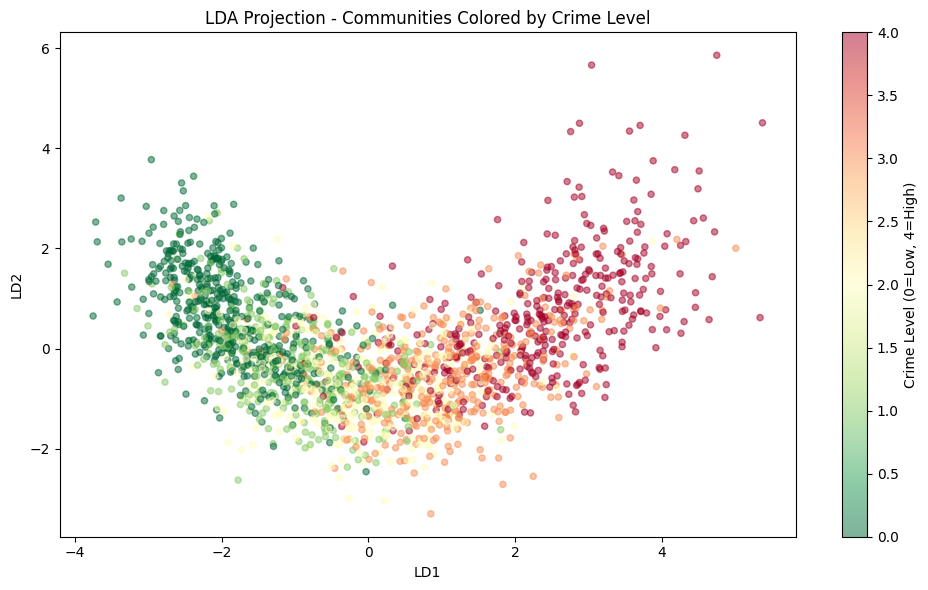

In [12]:
# LDA requires class labels - discretize target into bins
n_classes = 5
y_binned = pd.qcut(y, q=n_classes, labels=False, duplicates='drop')
actual_classes = len(np.unique(y_binned))
print(f"Target discretized into {actual_classes} classes for LDA")
print(f"Class distribution: {np.bincount(y_binned)}")

# LDA - max components = min(n_features, n_classes - 1)
max_lda_components = min(X_scaled.shape[1], actual_classes - 1)
lda = LDA(n_components=max_lda_components)
X_lda = lda.fit_transform(X_scaled, y_binned)
print(f"LDA reduced: {X_scaled.shape[1]} -> {X_lda.shape[1]} features")
print(f"LDA explained variance ratios: {lda.explained_variance_ratio_}")

# Visualize LDA projection
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1], c=y_binned, cmap='RdYlGn_r',
                     alpha=0.5, s=20)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA Projection - Communities Colored by Crime Level')
plt.colorbar(scatter, label='Crime Level (0=Low, 4=High)')
plt.tight_layout()
plt.savefig('../figures/task5_lda_projection.pdf', dpi=150, bbox_inches='tight')
plt.show()

### PCA 2D Visualisation

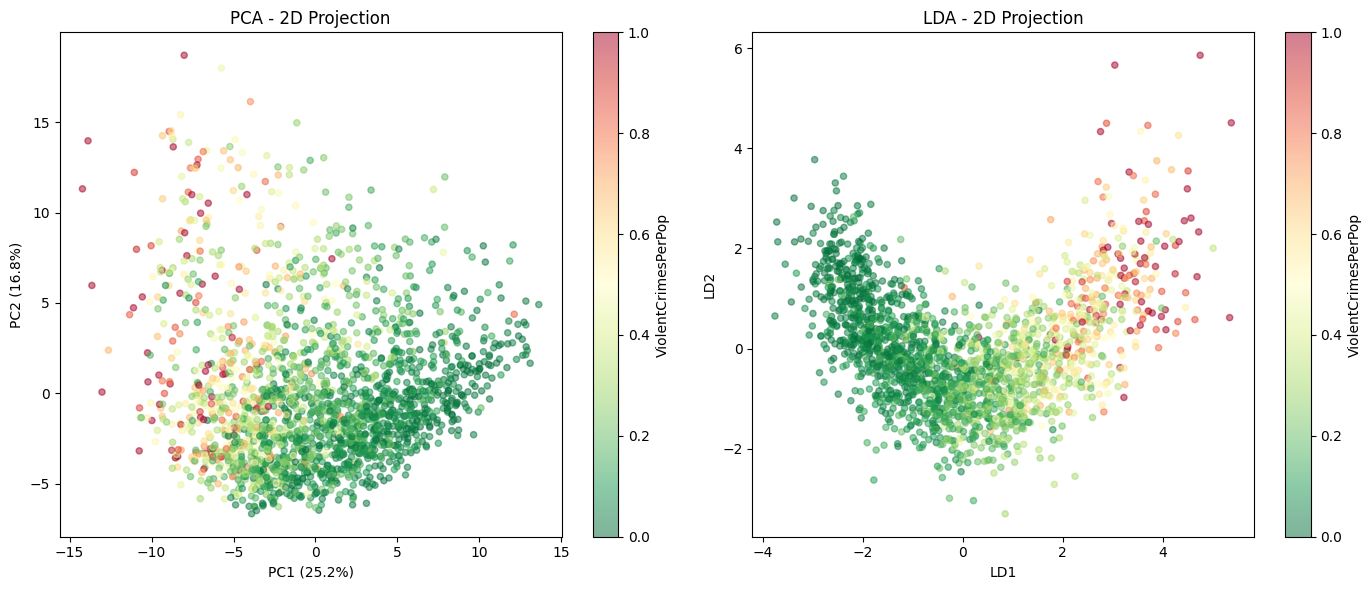

PCA 2D explains: 42.0% of total variance


In [13]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn_r',
                           alpha=0.5, s=20)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA - 2D Projection')
plt.colorbar(scatter1, ax=axes[0], label='ViolentCrimesPerPop')

scatter2 = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='RdYlGn_r',
                           alpha=0.5, s=20)
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('LDA - 2D Projection')
plt.colorbar(scatter2, ax=axes[1], label='ViolentCrimesPerPop')

plt.tight_layout()
plt.savefig('../figures/task5_2d_projections.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("PCA 2D explains: {:.1f}% of total variance".format(
    pca_2d.explained_variance_ratio_.sum() * 100))

### REGRESSION COMPARISON: Original vs PCA-reduced

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Models to compare
results = {}

# A) Ridge Regression on original features
ridge_orig = Ridge(alpha=1.0)
scores_orig = cross_val_score(ridge_orig, X_scaled, y, cv=cv, scoring='r2')
results['Ridge (Original)'] = scores_orig
print(f"Ridge (Original {X_scaled.shape[1]} features):  R² = {scores_orig.mean():.4f} ± {scores_orig.std():.4f}")

# B) Ridge on PCA-reduced features (95% variance)
ridge_pca = Ridge(alpha=1.0)
scores_pca = cross_val_score(ridge_pca, X_pca, y, cv=cv, scoring='r2')
results['Ridge (PCA-95%)'] = scores_pca
print(f"Ridge (PCA {X_pca.shape[1]} features):          R² = {scores_pca.mean():.4f} ± {scores_pca.std():.4f}")

# C) Ridge on fewer PCA components
for n_comp in [10, 20, 30]:
    pca_n = PCA(n_components=n_comp)
    X_pca_n = pca_n.fit_transform(X_scaled)
    scores = cross_val_score(Ridge(alpha=1.0), X_pca_n, y, cv=cv, scoring='r2')
    results[f'Ridge (PCA-{n_comp})'] = scores
    print(f"Ridge (PCA {n_comp} features):              R² = {scores.mean():.4f} ± {scores.std():.4f}")

# D) Random Forest on original
rf_orig = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_rf_orig = cross_val_score(rf_orig, X_scaled, y, cv=cv, scoring='r2')
results['RF (Original)'] = scores_rf_orig
print(f"\nRandom Forest (Original):                R² = {scores_rf_orig.mean():.4f} ± {scores_rf_orig.std():.4f}")

# E) Random Forest on PCA
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=cv, scoring='r2')
results['RF (PCA-95%)'] = scores_rf_pca
print(f"Random Forest (PCA {X_pca.shape[1]} features):  R² = {scores_rf_pca.mean():.4f} ± {scores_rf_pca.std():.4f}")

Ridge (Original 100 features):  R² = 0.6541 ± 0.0235
Ridge (PCA 35 features):          R² = 0.6426 ± 0.0263
Ridge (PCA 10 features):              R² = 0.6266 ± 0.0235
Ridge (PCA 20 features):              R² = 0.6357 ± 0.0239
Ridge (PCA 30 features):              R² = 0.6399 ± 0.0283

Random Forest (Original):                R² = 0.6432 ± 0.0382
Random Forest (PCA 35 features):  R² = 0.6140 ± 0.0248


### CLASSIFICATION COMPARISON: Original vs LDA vs PCA

In [15]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression - Original
lr_orig = LogisticRegression(max_iter=5000, random_state=42)
acc_orig = cross_val_score(lr_orig, X_scaled, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (Original {X_scaled.shape[1]} features): Acc = {acc_orig.mean():.4f} ± {acc_orig.std():.4f}")

# Logistic Regression - LDA
lr_lda = LogisticRegression(max_iter=5000, random_state=42)
acc_lda = cross_val_score(lr_lda, X_lda, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (LDA {X_lda.shape[1]} features):        Acc = {acc_lda.mean():.4f} ± {acc_lda.std():.4f}")

# Logistic Regression - PCA (same dim as LDA for fair comparison)
pca_lda_dim = PCA(n_components=X_lda.shape[1])
X_pca_lda_dim = pca_lda_dim.fit_transform(X_scaled)
lr_pca_low = LogisticRegression(max_iter=5000, random_state=42)
acc_pca_low = cross_val_score(lr_pca_low, X_pca_lda_dim, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (PCA {X_lda.shape[1]} features):        Acc = {acc_pca_low.mean():.4f} ± {acc_pca_low.std():.4f}")

# Logistic Regression - PCA 95%
lr_pca95 = LogisticRegression(max_iter=5000, random_state=42)
acc_pca95 = cross_val_score(lr_pca95, X_pca, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (PCA-95% {X_pca.shape[1]} features):    Acc = {acc_pca95.mean():.4f} ± {acc_pca95.std():.4f}")

# Random Forest - Classification
rf_cls_orig = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
acc_rf_orig = cross_val_score(rf_cls_orig, X_scaled, y_binned, cv=cv_strat, scoring='accuracy')
print(f"\nRandom Forest (Original):    Acc = {acc_rf_orig.mean():.4f} ± {acc_rf_orig.std():.4f}")

rf_cls_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
acc_rf_lda = cross_val_score(rf_cls_lda, X_lda, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Random Forest (LDA):         Acc = {acc_rf_lda.mean():.4f} ± {acc_rf_lda.std():.4f}")

Logistic Regression (Original 100 features): Acc = 0.5010 ± 0.0181
Logistic Regression (LDA 4 features):        Acc = 0.5732 ± 0.0234
Logistic Regression (PCA 4 features):        Acc = 0.4719 ± 0.0249
Logistic Regression (PCA-95% 35 features):    Acc = 0.5030 ± 0.0194

Random Forest (Original):    Acc = 0.5211 ± 0.0169
Random Forest (LDA):         Acc = 0.5371 ± 0.0084


### Regression performance vs Number of PCA components

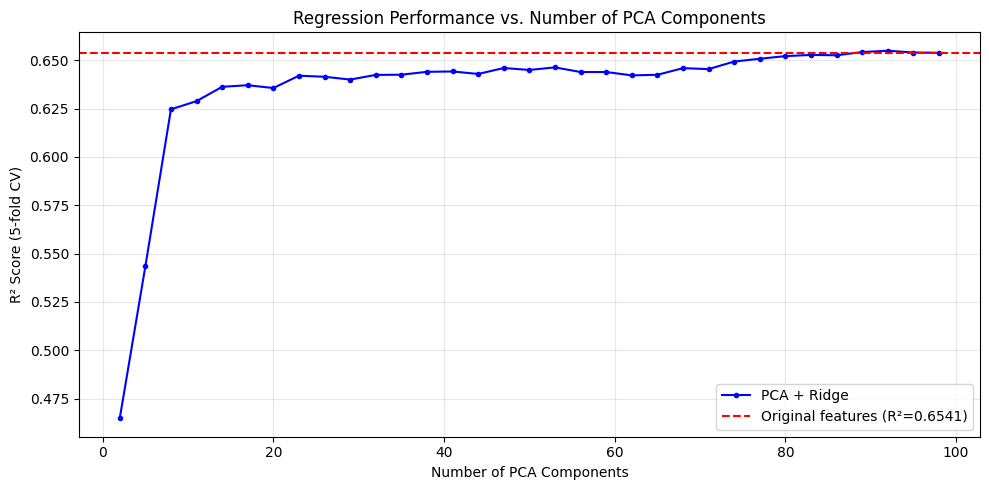

In [16]:
component_range = list(range(2, min(X_scaled.shape[1], 100), 3))
r2_scores = []

for n in component_range:
    pca_temp = PCA(n_components=n)
    X_temp = pca_temp.fit_transform(X_scaled)
    score = cross_val_score(Ridge(alpha=1.0), X_temp, y, cv=cv, scoring='r2').mean()
    r2_scores.append(score)

# Baseline: original features
baseline_r2 = scores_orig.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(component_range, r2_scores, 'b-o', markersize=3, label='PCA + Ridge')
ax.axhline(y=baseline_r2, color='r', linestyle='--', label=f'Original features (R²={baseline_r2:.4f})')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('R² Score (5-fold CV)')
ax.set_title('Regression Performance vs. Number of PCA Components')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/task5_performance_vs_components.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Feature loadings heatmap - PCA Interpretability

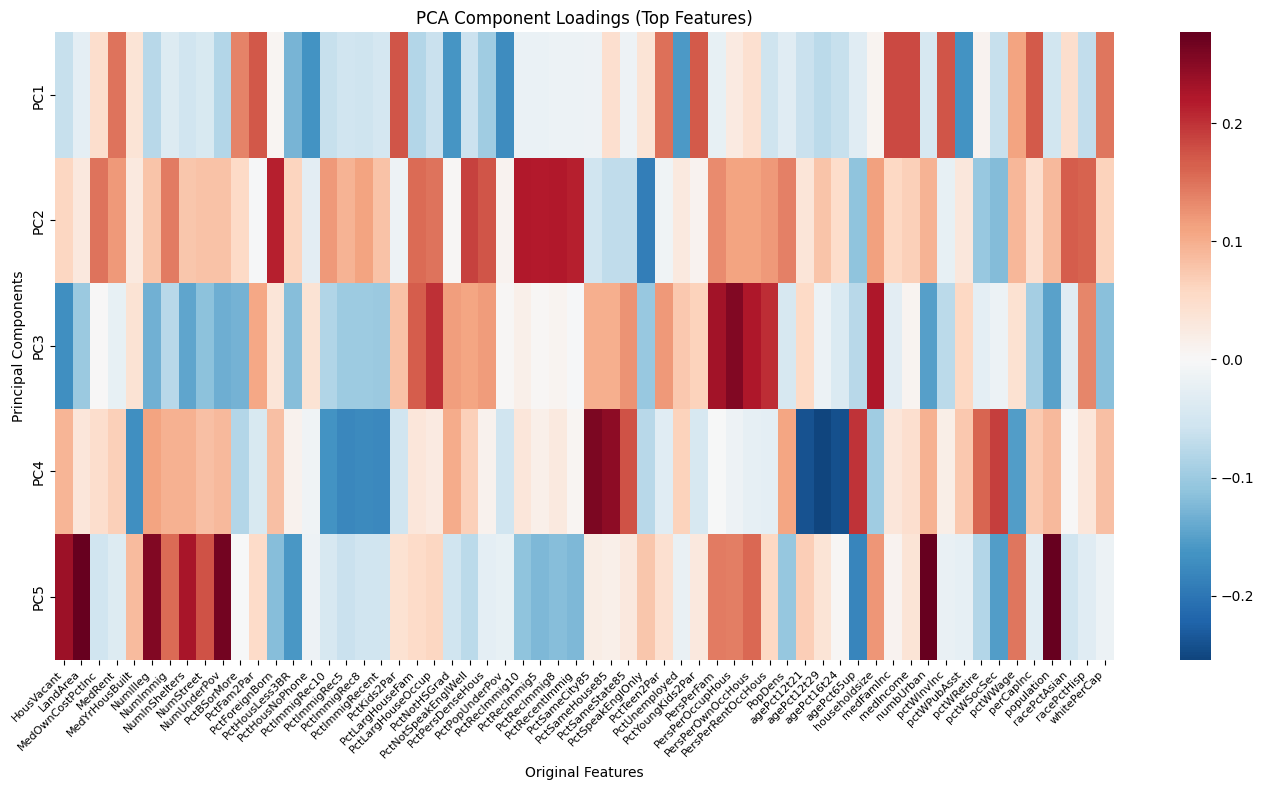

In [18]:
n_show = 5  # top PCs to show
n_features_show = 15  # top features per PC

fig, ax = plt.subplots(figsize=(14, 8))
loadings_df = pd.DataFrame(
    pca.components_[:n_show, :],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_show)]
)

# Select top features by absolute loading across first 5 PCs
top_features = set()
for i in range(n_show):
    abs_loadings = np.abs(pca.components_[i])
    top_idx = np.argsort(abs_loadings)[-n_features_show:]
    top_features.update([feature_names[j] for j in top_idx])

top_features = sorted(top_features)
loadings_subset = loadings_df[top_features]

sns.heatmap(loadings_subset, cmap='RdBu_r', center=0, annot=False,
            fmt='.2f', ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('PCA Component Loadings (Top Features)')
ax.set_xlabel('Original Features')
ax.set_ylabel('Principal Components')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/task5_pca_loadings_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Explainability Analysis

RF on Original features: R² = 0.6184
RF on PCA features:      R² = 0.6129

Top 10 most important features (RF on original):
  PctIlleg: 0.3275
  PctKids2Par: 0.2123
  racePctWhite: 0.0285
  PctFam2Par: 0.0228
  NumIlleg: 0.0144
  FemalePctDiv: 0.0132
  NumStreet: 0.0117
  MalePctDivorce: 0.0110
  PctPersDenseHous: 0.0109
  HousVacant: 0.0106

Top 10 most important PCA components (RF on PCA):
  PC1: 0.4394
  PC3: 0.0876
  PC2: 0.0479
  PC7: 0.0476
  PC8: 0.0400
  PC15: 0.0172
  PC32: 0.0165
  PC4: 0.0145
  PC5: 0.0141
  PC10: 0.0139


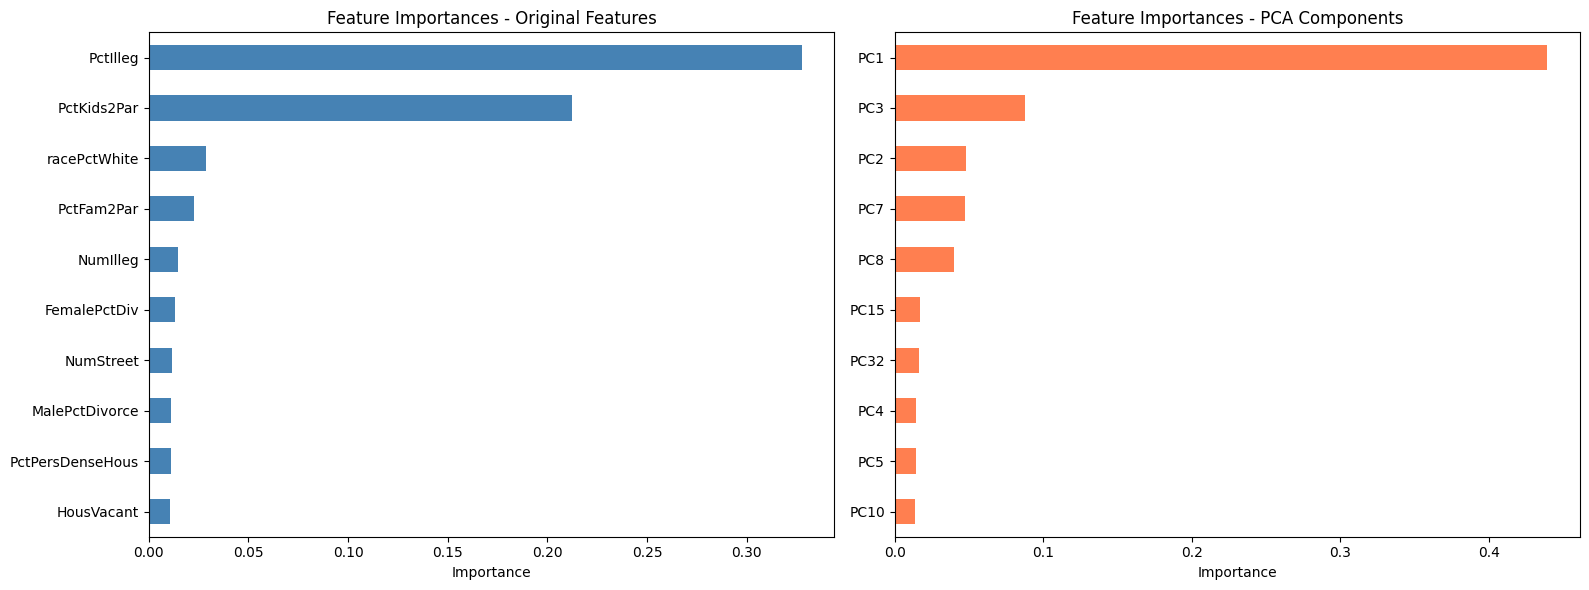

In [19]:
# Train models for SHAP analysis
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# PCA transform
pca_explain = PCA(n_components=n_95)
X_train_pca = pca_explain.fit_transform(X_train)
X_test_pca = pca_explain.transform(X_test)

# Original model - feature importances
rf_explain = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_explain.fit(X_train, y_train)
r2_orig = r2_score(y_test, rf_explain.predict(X_test))

# PCA model
rf_pca_explain = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca_explain.fit(X_train_pca, y_train)
r2_pca = r2_score(y_test, rf_pca_explain.predict(X_test_pca))

print(f"RF on Original features: R² = {r2_orig:.4f}")
print(f"RF on PCA features:      R² = {r2_pca:.4f}")

# Feature importances - Original
importances = pd.Series(rf_explain.feature_importances_, index=feature_names)
top_10 = importances.nlargest(10)
print(f"\nTop 10 most important features (RF on original):")
for name, imp in top_10.items():
    print(f"  {name}: {imp:.4f}")

# Feature importances - PCA (less interpretable!)
pca_importances = pd.Series(rf_pca_explain.feature_importances_,
                            index=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
top_pca = pca_importances.nlargest(10)
print(f"\nTop 10 most important PCA components (RF on PCA):")
for name, imp in top_pca.items():
    print(f"  {name}: {imp:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_10.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances - Original Features')
axes[0].set_xlabel('Importance')

top_pca.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importances - PCA Components')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../figures/task5_feature_importances.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Mapping PCA back to original features

In [20]:
# For the top 3 most important PCs, show what original features they represent
top_3_pcs = pca_importances.nlargest(3).index.tolist()
for pc_name in top_3_pcs:
    pc_idx = int(pc_name.replace('PC', '')) - 1
    loadings = pd.Series(pca_explain.components_[pc_idx], index=feature_names)
    print(f"\n{pc_name} (importance={pca_importances[pc_name]:.4f}, "
          f"variance explained={pca_explain.explained_variance_ratio_[pc_idx]*100:.1f}%):")
    top_pos = loadings.nlargest(5)
    top_neg = loadings.nsmallest(5)
    print(f"  Positive loadings: {', '.join([f'{n}({v:.3f})' for n, v in top_pos.items()])}")
    print(f"  Negative loadings: {', '.join([f'{n}({v:.3f})' for n, v in top_neg.items()])}")


PC1 (importance=0.4394, variance explained=24.7%):
  Positive loadings: medFamInc(0.180), medIncome(0.178), PctKids2Par(0.175), pctWInvInc(0.174), PctYoungKids2Par(0.172)
  Negative loadings: PctPopUnderPov(-0.173), pctWPubAsst(-0.165), PctHousNoPhone(-0.165), PctNotHSGrad(-0.162), PctUnemployed(-0.157)

PC3 (importance=0.0876, variance explained=9.7%):
  Positive loadings: PersPerOccupHous(0.254), householdsize(0.230), PersPerFam(0.230), PersPerOwnOccHous(0.224), PersPerRentOccHous(0.209)
  Negative loadings: HousVacant(-0.184), numbUrban(-0.165), NumInShelters(-0.163), population(-0.163), NumIlleg(-0.152)

PC2 (importance=0.0479, variance explained=16.8%):
  Positive loadings: PctRecImmig10(0.218), PctRecImmig8(0.218), PctRecImmig5(0.216), PctRecentImmig(0.213), PctForeignBorn(0.212)
  Negative loadings: PctSpeakEnglOnly(-0.189), PctBornSameState(-0.126), pctWSocSec(-0.117), racePctWhite(-0.112), agePct65up(-0.108)


### Summary Table

In [21]:
pd.DataFrame({
    'Method': ['Original', f'PCA (10 comp)', f'PCA (20 comp)', f'PCA ({n_95} comp, 95%)',
               'LDA (classification)'],
    'Dimensions': [X_scaled.shape[1], 10, 20, n_95, max_lda_components],
    'Reduction %': [0,
                    round((1 - 10/X_scaled.shape[1])*100, 1),
                    round((1 - 20/X_scaled.shape[1])*100, 1),
                    round((1 - n_95/X_scaled.shape[1])*100, 1),
                    round((1 - max_lda_components/X_scaled.shape[1])*100, 1)],
    'Interpretable': ['Yes - direct features', 'Limited - linear combos',
                      'Limited - linear combos', 'Limited - linear combos',
                      'Limited - class-driven combos'],
})

,Method,Dimensions,Reduction %,Interpretable
0,Original,100,0.0,Yes - direct features
1,PCA (10 comp),10,90.0,Limited - linear combos
2,PCA (20 comp),20,80.0,Limited - linear combos
3,"PCA (35 comp, 95%)",35,65.0,Limited - linear combos
4,LDA (classification),4,96.0,Limited - class-driven combos
